In [22]:
import torch
from torch import nn
from torchvision import transforms

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

### Визуализация предсказанной маски

In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [12]:
class MBConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, expansion_rate=1, stride=1, kernel_size=3):
        super().__init__()
    
        self.skip_connection = (stride == 1) and (in_channels == out_channels)
        expanded_channels = in_channels * expansion_rate
        padding_val = (kernel_size - 1) // 2
        squeeze_channels = max(1, expanded_channels // 4)

        self.expantion = nn.Identity()
        if expansion_rate != 1:
            self.expantion = nn.Sequential(
                nn.Conv2d(in_channels, expanded_channels, 
                          kernel_size=1, padding=0, bias=False),
                nn.BatchNorm2d(expanded_channels),
                nn.SiLU(inplace=True)
            )

        self.depthwize_convolution = nn.Sequential(
            nn.Conv2d(expanded_channels, expanded_channels, 
                      kernel_size=kernel_size, stride=stride, padding=padding_val, groups=expanded_channels, bias=False),
            nn.BatchNorm2d(expanded_channels),
            nn.SiLU(inplace=True)
        )

        self.SE_block = nn.Sequential(
            nn.AdaptiveAvgPool2d(output_size=(1, 1)),
            nn.Conv2d(
                in_channels=expanded_channels, out_channels=squeeze_channels, kernel_size=1
            ),
            nn.SiLU(inplace=True),
            nn.Conv2d(
                in_channels=squeeze_channels, out_channels=expanded_channels, kernel_size=1
            ),
            nn.Sigmoid()
        )

        self.projection = nn.Sequential(
            nn.Conv2d(in_channels=expanded_channels, out_channels=out_channels, kernel_size=1, padding=0, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        
    def forward(self, x):
        input = x
        output = self.expantion(x)
        output = self.depthwize_convolution(output)
        output = self.SE_block(output) * output
        output = self.projection(output) 
        if self.skip_connection:
            output += input

        return output


In [13]:
class ClassificationNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(
            in_channels=3, out_channels=64, kernel_size=3, padding=1, bias=False
            ),
            nn.BatchNorm2d(64),
            nn.SiLU(inplace=True)
        )

        self.MBC1 = MBConvBlock(in_channels=64, out_channels=128, expansion_rate=1, stride=2, kernel_size=3)
        self.MBC2 = MBConvBlock(in_channels=128, out_channels=128, expansion_rate=6, stride=2, kernel_size=5)
        self.MBC3 = MBConvBlock(in_channels=128, out_channels=128, expansion_rate=6, stride=1, kernel_size=5)

        self.conv2 = nn.Sequential(
            nn.Conv2d(
            in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1, bias=False
            ),
            nn.BatchNorm2d(256),
            nn.SiLU(inplace=True)
        )
        self.gap = nn.AdaptiveAvgPool2d(output_size=1)
        self.fc = nn.Linear(256, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = self.MBC1(x)
        x = self.MBC2(x)
        x = self.MBC3(x)
        x = self.conv2(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)

        return x


In [14]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)
    
class UNetWithBackbone(nn.Module):
    def __init__(self, backbone, n_classes=1):
        super().__init__()

        self.backbone = backbone

        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(256, 128)
    
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(192, 64)

        self.up3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(96, 32)
        
        self.final = nn.Conv2d(32, n_classes, kernel_size=1)
        
    def forward(self, x):

        x1 = self.backbone.conv1(x)
        x2 = self.backbone.MBC1(x1)
        x3 = self.backbone.MBC2(x2)
        x3_refined = self.backbone.MBC3(x3)
        
        bottleneck = self.backbone.conv2(x3_refined)
    
        u1 = self.up1(bottleneck)
        cat1 = torch.cat([x3_refined, u1], dim=1) 
        d1 = self.dec1(cat1)
        u2 = self.up2(d1)
        cat2 = torch.cat([x2, u2], dim=1)
        d2 = self.dec2(cat2)
        u3 = self.up3(d2)
        cat3 = torch.cat([x1, u3], dim=1)
        d3 = self.dec3(cat3)
        
        return self.final(d3)

In [15]:
def predict_and_visualize(image_path, model, threshold=0.5):
    """
    image_path: путь до .png картинки
    model: обученная модель
    threshold: порог для бинаризации (обычно 0.5)
    """

    original_image = Image.open(image_path).convert('RGB')
    
    transform_pipeline = transforms.Compose([
        transforms.Resize((128, 128)), 
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    input_tensor = transform_pipeline(original_image)
    input_batch = input_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad(): 
        output = model(input_batch)
        probs = torch.sigmoid(output)
        probs = probs.squeeze().cpu().numpy()
        
    binary_mask = (probs > threshold).astype(np.uint8)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original_image.resize((128, 128)))
    ax[0].set_title("Исходное изображение")
    ax[0].axis('off')
    
    ax[1].imshow(binary_mask, cmap='gray')
    ax[1].set_title("Предсказанная маска")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

In [16]:
PATH_TO_WEIGHTS = 'C:/python/try_to_nn/CV_ITMO/HW_03/UNet_backbone/unet_with_backbone.pth'

model = torch.load(PATH_TO_WEIGHTS, map_location=device, weights_only=False)

In [20]:
def predict_and_visualize(image_path, model, threshold=0.5):
    """
    image_path: путь до .png картинки
    model: обученная модель
    threshold: порог для бинаризации (обычно 0.5)
    """

    original_image = Image.open(image_path).convert('RGB')
    
    transform_pipeline = transforms.Compose([
        transforms.Resize((128, 128)), 
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    
    input_tensor = transform_pipeline(original_image)
    input_batch = input_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad(): 
        output = model(input_batch)
        probs = torch.sigmoid(output)
        probs = probs.squeeze().cpu().numpy()
        
    binary_mask = (probs > threshold).astype(np.uint8)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(original_image.resize((128, 128)))
    ax[0].set_title("Исходное изображение")
    ax[0].axis('off')
    
    ax[1].imshow(binary_mask, cmap='gray')
    ax[1].set_title("Предсказанная маска")
    ax[1].axis('off')
    
    plt.tight_layout()
    plt.show()

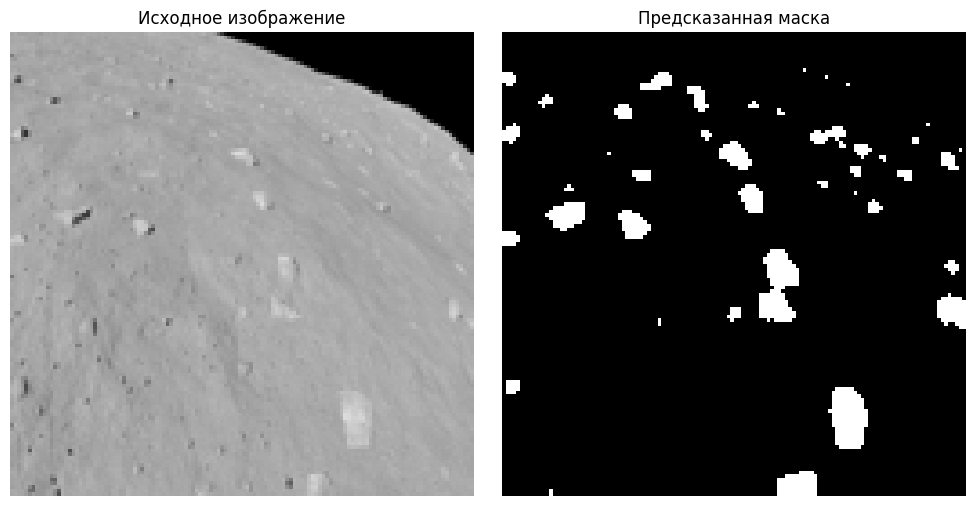

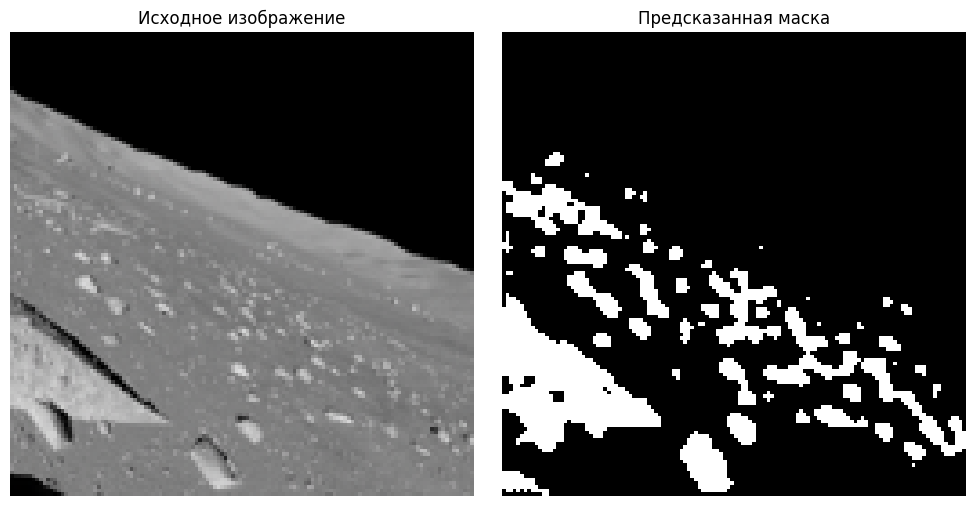

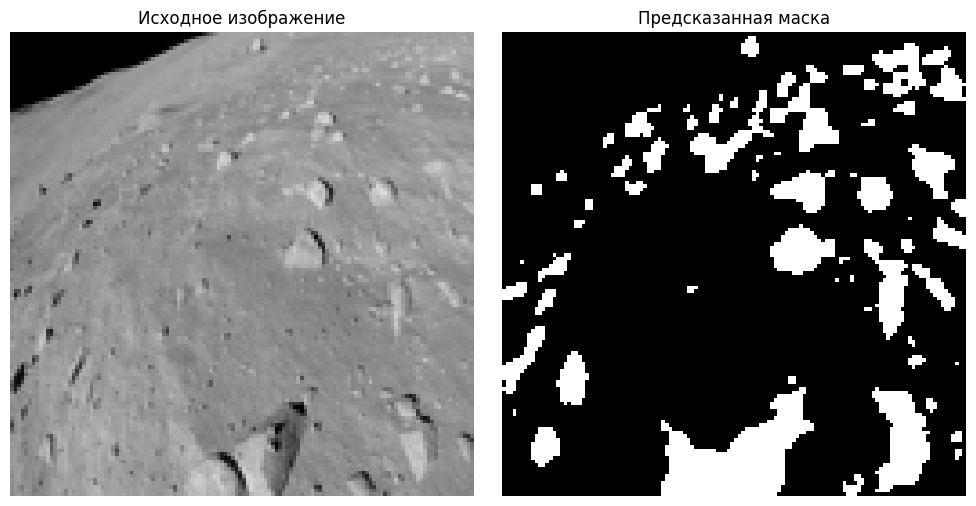

In [23]:
for i, path in enumerate(os.listdir("C:/python/try_to_nn/data/MOON_SEGMENTATION_BINARY/images/render")):
    start = 5
    end = 8
    if i in np.arange(start, end):
        img_path=f"C:/python/try_to_nn/data/MOON_SEGMENTATION_BINARY/images/render/{path}"
        predict_and_visualize(image_path=img_path,
                            model=model)
    elif i > end:
        break